# 01 — Tiền Xử Lý Dữ Liệu (Pipeline Chung)

Notebook này thực hiện **toàn bộ bước tiền xử lý dùng chung** trước khi đưa vào bất kỳ mô hình nào.
Output là 3 file CSV sạch, sẵn sàng để notebook mô hình tải vào.

```
Load Data → EDA → Cleaning → Text Preprocessing → Rule-based Labeling → Class Weights → Save
```

**Input :** `data/raw/*.csv`  
**Output:** `data/processed/*_labeled.csv` + `class_weights.json`


## 3.1 Khởi tạo & Tải dữ liệu

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install underthesea -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import re, unicodedata, warnings, os, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from underthesea import word_tokenize
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings('ignore')

# ⚠️  CHỈNH SỬA BASE_PATH CHO PHÙ HỢP VỚI DRIVE CỦA BẠN
BASE_PATH = '/content/drive/MyDrive/sentiment_analyst/'
RAW_PATH  = BASE_PATH + 'data/raw/'        # CSV gốc (không chỉnh sửa)
PROC_PATH = BASE_PATH + 'data/processed/'  # CSV đã xử lý + class_weights.json
FIG_PATH  = BASE_PATH + 'outputs/figures/' # Biểu đồ cho báo cáo

for p in [RAW_PATH, PROC_PATH, FIG_PATH]:
    os.makedirs(p, exist_ok=True)

ASPECT_COLUMNS = ['Price','Shipping','Outlook','Quality','Size','Shop_Service','General','Others']
VOTE_COLUMNS   = ['Price','Shipping','Outlook','Quality','Size','Shop_Service','General']  # loại Others
LABEL_MAP      = {-1:'None', 0:'Negative', 1:'Positive', 2:'Neutral'}
LABEL_COLORS   = {'None':'#9E9E9E','Negative':'#EF5350','Positive':'#66BB6A','Neutral':'#FFA726'}

# ⚠️  Thứ tự này phải khớp với tất cả notebook model
LABEL_ENCODE = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
LABEL_DECODE = {v: k for k, v in LABEL_ENCODE.items()}

train_df = pd.read_csv(RAW_PATH + 'train_data.csv')
val_df   = pd.read_csv(RAW_PATH + 'val_data.csv')
test_df  = pd.read_csv(RAW_PATH + 'test_data.csv')

print('Train:', train_df.shape, '| Val:', val_df.shape, '| Test:', test_df.shape)
train_df.head(3)


Train: (8424, 9) | Val: (936, 9) | Test: (2340, 9)


,Review,Price,Shipping,Outlook,Quality,Size,Shop_Service,General,Others
0,"Giày đẹp, đi êm lắm",-1,-1,1,1,-1,-1,-1,-1
1,Mình săn sale với giá khá rẻ Chất lượng ok Sh...,1,1,-1,1,-1,-1,-1,-1
2,Hình ảnh và video chỉ mang tính chất minh họa ...,1,1,-1,-1,-1,-1,1,-1


## 3.2 Khám phá dữ liệu (EDA)

In [4]:
print('=== TRAIN INFO ===')
train_df.info()
print('\n=== MISSING VALUES ===')
print(train_df.isnull().sum())


=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8424 entries, 0 to 8423
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Review        8424 non-null   object
 1   Price         8424 non-null   int64 
 2   Shipping      8424 non-null   int64 
 3   Outlook       8424 non-null   int64 
 4   Quality       8424 non-null   int64 
 5   Size          8424 non-null   int64 
 6   Shop_Service  8424 non-null   int64 
 7   General       8424 non-null   int64 
 8   Others        8424 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 592.4+ KB

=== MISSING VALUES ===
Review          0
Price           0
Shipping        0
Outlook         0
Quality         0
Size            0
Shop_Service    0
General         0
Others          0
dtype: int64


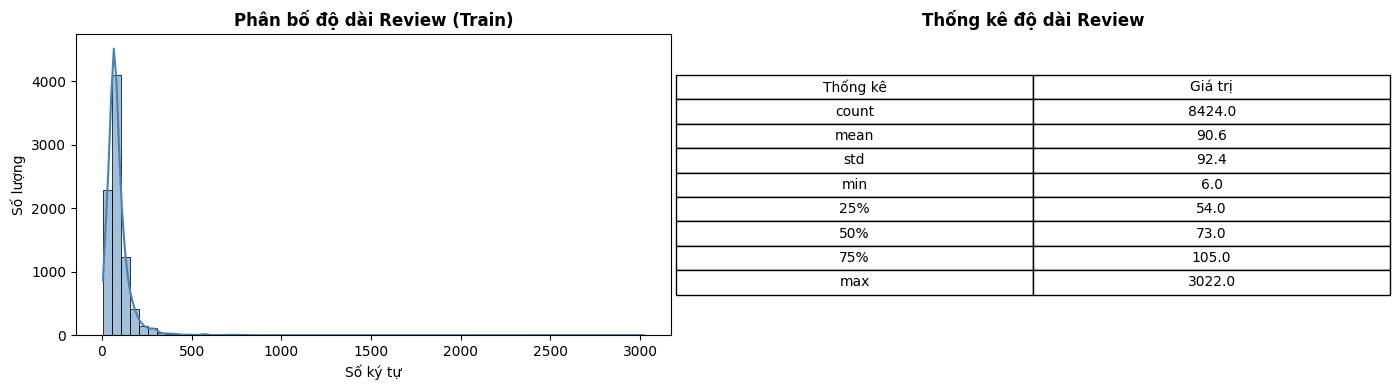

In [5]:
# Phân bố độ dài review
lengths = train_df['Review'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(lengths, bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Phân bố độ dài Review (Train)', fontweight='bold')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Số lượng')

stats = lengths.describe()
axes[1].axis('off')
table_data = [[k, f'{v:.1f}'] for k, v in stats.items()]
tbl = axes[1].table(cellText=table_data, colLabels=['Thống kê','Giá trị'],
                    loc='center', cellLoc='center')
tbl.scale(1.2, 1.5)
axes[1].set_title('Thống kê độ dài Review', fontweight='bold')
plt.tight_layout()
plt.show()


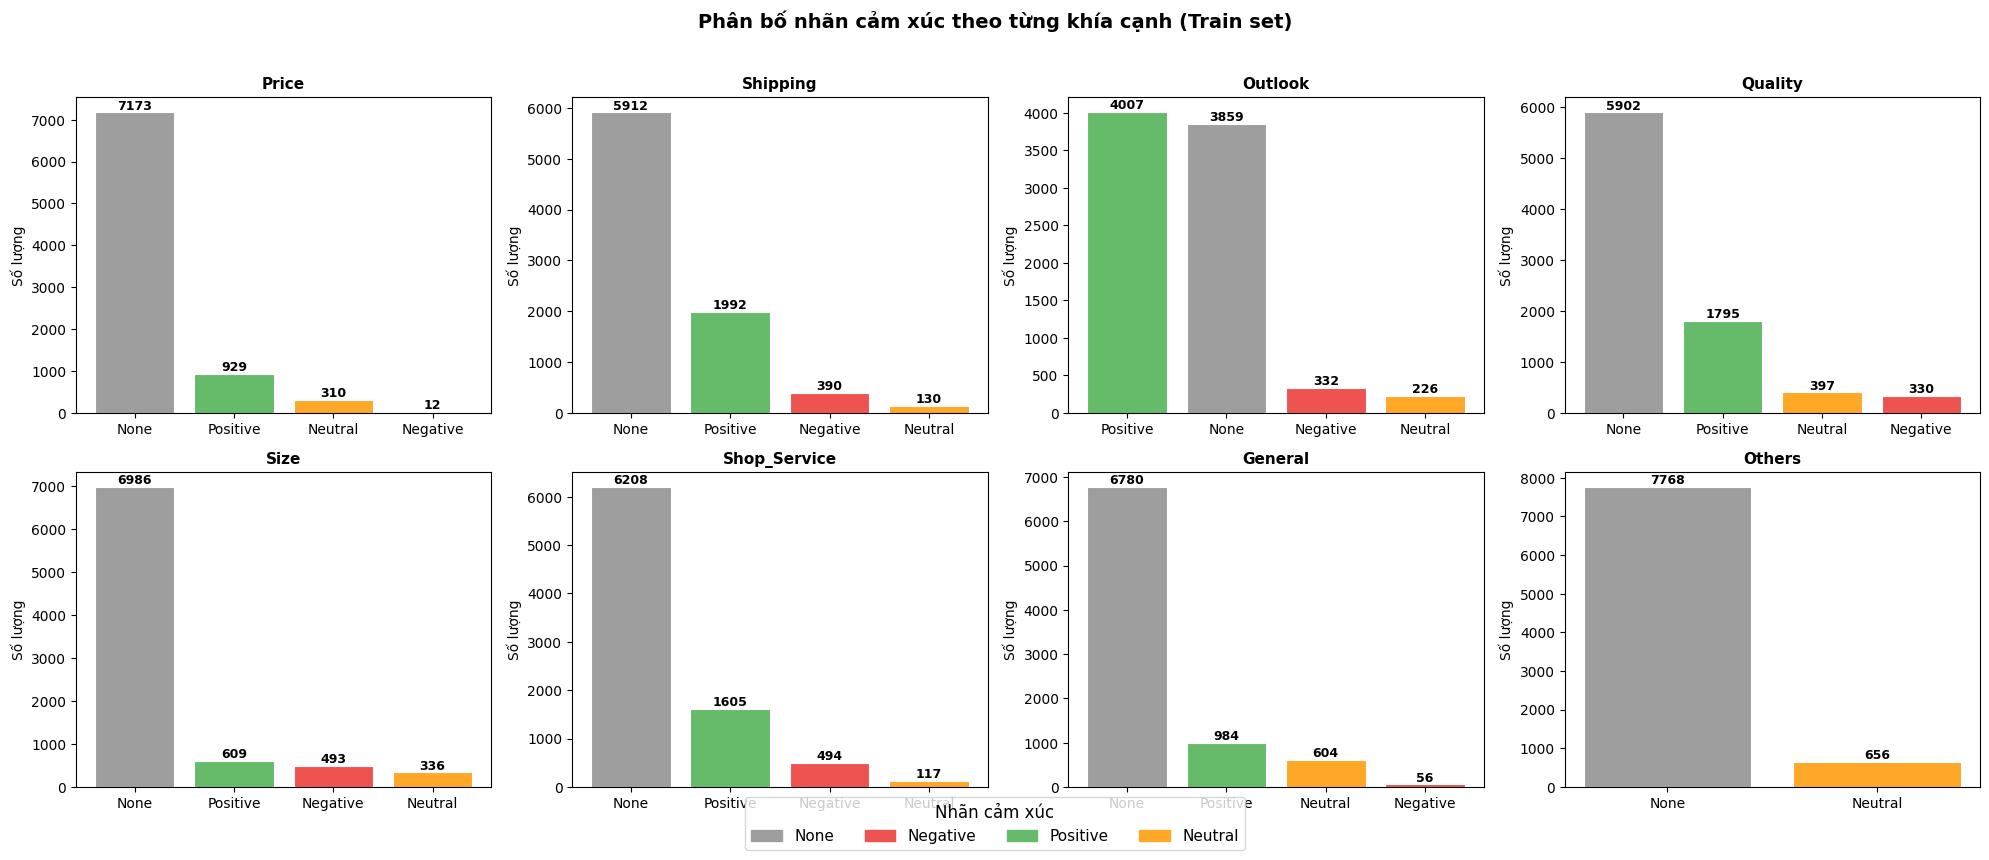

In [6]:
# Phân bố nhãn theo từng khía cạnh — TRAIN SET
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(ASPECT_COLUMNS):
    counts = train_df[col].map(LABEL_MAP).value_counts()
    colors = [LABEL_COLORS.get(l, '#9E9E9E') for l in counts.index]
    bars = axes[i].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Số lượng')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=11,
           title='Nhãn cảm xúc', title_fontsize=12, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Phân bố nhãn cảm xúc theo từng khía cạnh (Train set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'label_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


In [7]:
# Kiểm tra số review trùng lặp (thống kê, không xóa)
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dup = df['Review'].duplicated().sum()
    print(f'[{name}] Trùng lặp: {dup}/{len(df)} ({dup/len(df)*100:.2f}%)')


[Train] Trùng lặp: 1/8424 (0.01%)
[Val] Trùng lặp: 0/936 (0.00%)
[Test] Trùng lặp: 0/2340 (0.00%)


## 3.3 Làm sạch dữ liệu cơ bản

In [8]:
def basic_cleaning(df):
    df = df.copy()
    df = df.dropna(subset=['Review'])                     # Xóa NaN
    df = df[df['Review'].str.strip() != '']              # Xóa chuỗi rỗng
    # KHÔNG drop_duplicates: trong TMĐT nhiều user có thể đánh giá giống nhau
    return df.reset_index(drop=True)

train_df = basic_cleaning(train_df)
val_df   = basic_cleaning(val_df)
test_df  = basic_cleaning(test_df)

print('Sau làm sạch — Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))


Sau làm sạch — Train: 8424 | Val: 936 | Test: 2340


## 3.4 Pipeline Tiền Xử Lý Văn Bản

Thứ tự: Lowercase → Unicode NFC → URL/email/hashtag/mention → Ký tự kéo dài → Emoji → Teencode → Dấu câu → Word segmentation


In [9]:
teencode_dict = {
    'ko':'không','k':'không','kh':'không','khong':'không',
    'đc':'được','dc':'được',
    'cx':'cũng',
    'nma':'nhưng mà',
    'sp':'sản phẩm',
    'mn':'mọi người','mng':'mọi người',
    'vl':'rất','vkl':'rất',
    'oke':'ok','okie':'ok','oki':'ok','okela':'ok','okila':'ok',
    'ship':'giao hàng',
    'ib':'nhắn_tin','rep':'phản_hồi','feedback':'đánh_giá',
}

# Chỉ 2 token: tích_cực / tiêu_cực — giảm vocabulary, thống nhất tín hiệu
emoji_dict = {
    # Positive
    '❤️':'tích_cực','🧡':'tích_cực','💛':'tích_cực','💚':'tích_cực',
    '💙':'tích_cực','💜':'tích_cực','🤍':'tích_cực','❣️':'tích_cực',
    '💗':'tích_cực','💓':'tích_cực','😍':'tích_cực','🥰':'tích_cực',
    '😊':'tích_cực','😄':'tích_cực','😁':'tích_cực','🤩':'tích_cực',
    '😻':'tích_cực','🌟':'tích_cực','⭐':'tích_cực','👍':'tích_cực',
    '💪':'tích_cực','✅':'tích_cực','👌':'tích_cực',
    # Negative
    '😡':'tiêu_cực','😠':'tiêu_cực','🤬':'tiêu_cực','😤':'tiêu_cực',
    '👎':'tiêu_cực','❌':'tiêu_cực','😭':'tiêu_cực','😢':'tiêu_cực','🥲':'tiêu_cực',
}

def preprocess_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)   # #đẹp → đẹp
    text = re.sub(r'@\w+', '', text)
    for emo, val in emoji_dict.items():
        text = text.replace(emo, f' {val} ')
    text = re.sub(r'(.)\1{2,}', r'\1', text) # ký tự kéo dài
    words = [teencode_dict.get(w, w) for w in text.split()]
    text  = ' '.join(words)
    text  = re.sub(r'!+', '!', text)
    text  = re.sub(r'\?+', '?', text)
    text  = re.sub(r'[^\w\s!?_]', ' ', text)
    text  = re.sub(r'\s+', ' ', text).strip()
    if text: text = word_tokenize(text, format='text')
    return text

# Demo
samples = [
    'Giao hàng nhanh 👍, sp đẹppppp lắm mn ơi k mua là tiếc!!!',
    'ship nhanh vkl ❤️❤️ ko ngờ oke vậy nha',
]
print('=== DEMO TIỀN XỬ LÝ ===')
for s in samples:
    print(f'  Gốc : {s}')
    print(f'  Xử lý: {preprocess_text(s)}')
    print()


=== DEMO TIỀN XỬ LÝ ===
  Gốc : Giao hàng nhanh 👍, sp đẹppppp lắm mn ơi k mua là tiếc!!!
  Xử lý: giao hàng nhanh tích_cực sản_phẩm đẹp lắm mọi người ơi không mua là tiếc !

  Gốc : ship nhanh vkl ❤️❤️ ko ngờ oke vậy nha
  Xử lý: giao hàng nhanh rất tích_cực_tích_cực không ngờ ok vậy nha



In [10]:
# Áp dụng pipeline cho toàn bộ dữ liệu
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'Đang xử lý {name}...')
    df['Review'] = df['Review'].apply(preprocess_text)

# Xóa câu rỗng sau xử lý
train_df = train_df[train_df['Review'].str.strip() != ''].reset_index(drop=True)
val_df   = val_df[val_df['Review'].str.strip() != ''].reset_index(drop=True)
test_df  = test_df[test_df['Review'].str.strip() != ''].reset_index(drop=True)

print('\n✅ Hoàn thành — Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))


Đang xử lý Train...
Đang xử lý Val...
Đang xử lý Test...

✅ Hoàn thành — Train: 8423 | Val: 935 | Test: 2339


## 3.5 Phân tích Mất Cân Bằng Dữ Liệu (Aspect-level EDA)

> **Phạm vi:** Phân tích mức độ mất cân bằng **theo từng khía cạnh** (EDA tham khảo).  
> Class weights thực dùng cho model được tính ở **Section 3.6.2**.


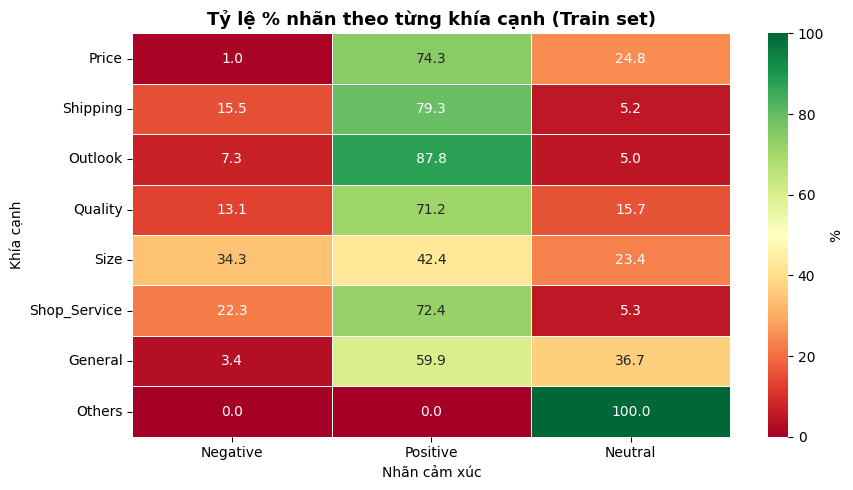

In [11]:
ratio_data = {}
for col in ASPECT_COLUMNS:
    subset = train_df[train_df[col] != -1][col]
    counts = subset.value_counts(normalize=True).rename(LABEL_MAP) * 100
    ratio_data[col] = counts

ratio_df = pd.DataFrame(ratio_data).T.fillna(0)
for lbl in ['Negative', 'Positive', 'Neutral']:
    if lbl not in ratio_df.columns: ratio_df[lbl] = 0
ratio_df = ratio_df[['Negative', 'Positive', 'Neutral']]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ratio_df, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': '%'})
ax.set_title('Tỷ lệ % nhãn theo từng khía cạnh (Train set)', fontweight='bold', fontsize=13)
ax.set_xlabel('Nhãn cảm xúc')
ax.set_ylabel('Khía cạnh')
plt.tight_layout()
plt.savefig(FIG_PATH + 'imbalance_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## 3.6 Gán nhãn tổng hợp (Rule-based Labeling)

| Điều kiện | Nhãn |
|-----------|------|
| Chỉ có Positive | **Positive** |
| Chỉ có Negative | **Negative** |
| Có cả Positive lẫn Negative | **Neutral** |
| Chỉ có Neutral(2) | **Neutral** |
| Không có aspect nào | **Loại bỏ** |

> Cột `Others` bị loại khỏi voting (spam/lạc đề).


In [12]:
def get_sentiment(row):
    votes = [row[a] for a in VOTE_COLUMNS if row[a] != -1]
    if not votes: return None
    pos = votes.count(1)
    neg = votes.count(0)
    if pos == 0 and neg == 0: return 'Neutral'
    if neg == 0: return 'Positive'
    if pos == 0: return 'Negative'
    return 'Neutral'   # hỗn hợp → cảm xúc trung tính

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    df['sentiment'] = df.apply(get_sentiment, axis=1)
    print(f'[{name}] Phân bố nhãn:')
    print(df['sentiment'].value_counts(dropna=False).to_string())
    print()


[Train] Phân bố nhãn:
sentiment
Positive    5484
Neutral     1486
Negative     790
None         663

[Val] Phân bố nhãn:
sentiment
Positive    612
Neutral     151
None         90
Negative     82

[Test] Phân bố nhãn:
sentiment
Positive    1499
Neutral      416
Negative     231
None         193



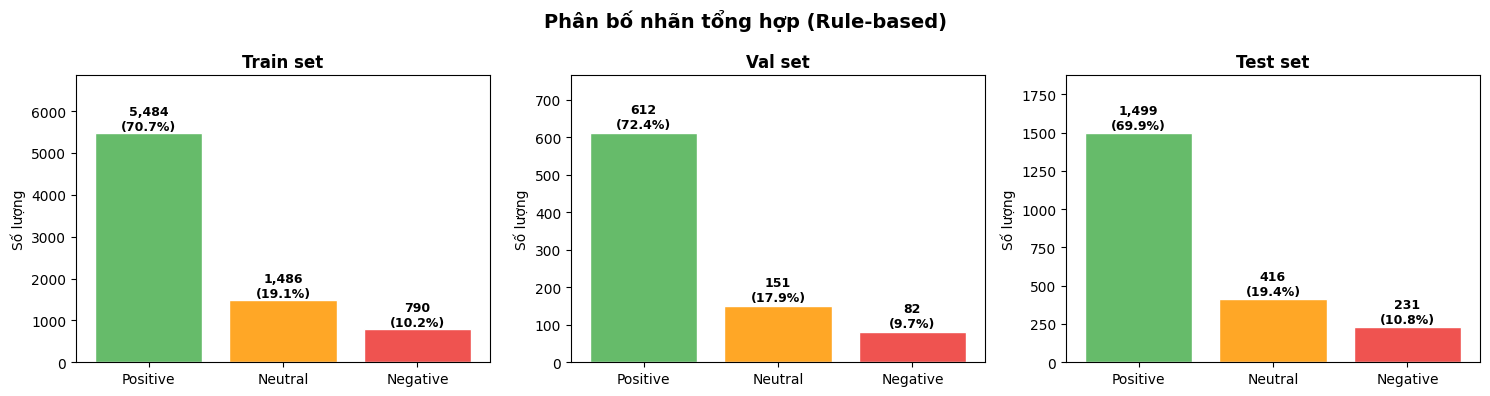

In [13]:
# Phân bố nhãn — biểu đồ
palette = {'Positive':'#66BB6A', 'Neutral':'#FFA726', 'Negative':'#EF5350'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df['sentiment'].value_counts().reindex(['Positive','Neutral','Negative']).fillna(0)
    total  = counts.sum()
    bars   = ax.bar(counts.index, counts.values,
                    color=[palette[l] for l in counts.index], edgecolor='white')
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(val):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{name} set', fontweight='bold', fontsize=12)
    ax.set_ylabel('Số lượng')
    ax.set_ylim(0, counts.max() * 1.25)

plt.suptitle('Phân bố nhãn tổng hợp (Rule-based)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'sentiment_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


In [14]:
# Phân tích edge case: pos >= 3*neg bị gán Neutral — limitation cần nêu báo cáo
def is_edge_case(row):
    votes = [row[a] for a in VOTE_COLUMNS if row[a] != -1]
    pos = votes.count(1); neg = votes.count(0)
    return pos > 0 and neg > 0 and pos >= 3 * neg

edge_cases = train_df[train_df.apply(is_edge_case, axis=1)].copy()
edge_cases['pos_count'] = edge_cases[VOTE_COLUMNS].apply(
    lambda r: [v for v in r if v != -1].count(1), axis=1)
edge_cases['neg_count'] = edge_cases[VOTE_COLUMNS].apply(
    lambda r: [v for v in r if v != -1].count(0), axis=1)

print(f'EDGE CASES (pos >= 3*neg → Neutral): {len(edge_cases)}/{len(train_df)} ({len(edge_cases)/len(train_df)*100:.2f}%)')
print('→ Ghi chú vào báo cáo: Limitation của rule-based approach.')


EDGE CASES (pos >= 3*neg → Neutral): 48/8423 (0.57%)
→ Ghi chú vào báo cáo: Limitation của rule-based approach.


In [15]:
# Drop các dòng không có nhãn
before = {n: len(d) for n, d in [('train',train_df),('val',val_df),('test',test_df)]}
train_df = train_df.dropna(subset=['sentiment']).reset_index(drop=True)
val_df   = val_df.dropna(subset=['sentiment']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['sentiment']).reset_index(drop=True)

print('Sau khi loại bỏ dòng không có nhãn:')
for name, df, b in [('Train',train_df,before['train']),
                     ('Val',val_df,before['val']),
                     ('Test',test_df,before['test'])]:
    print(f'  [{name}] {b:,} → {len(df):,}  (loại {b-len(df):,} dòng)')


Sau khi loại bỏ dòng không có nhãn:
  [Train] 8,423 → 7,760  (loại 663 dòng)
  [Val] 935 → 845  (loại 90 dòng)
  [Test] 2,339 → 2,146  (loại 193 dòng)


### 3.6.1 EDA nhãn tổng hợp

In [16]:
label_order = ['Positive', 'Neutral', 'Negative']
palette     = {'Positive':'#66BB6A', 'Neutral':'#FFA726', 'Negative':'#EF5350'}
counts = train_df['sentiment'].value_counts().reindex(label_order)
total  = counts.sum()

print('=== PHÂN BỐ NHÃN TỔNG HỢP (TRAIN SET) ===')
for label, cnt in counts.items():
    pct = cnt / total * 100
    bar = '█' * int(pct / 2)
    print(f'  {label:10s}: {cnt:5,} ({pct:5.1f}%)  {bar}')

imb = counts.max() / counts.min()
print(f'\nImbalance ratio: {imb:.1f}x')
if imb > 5:   print('⚠️  Mất cân bằng nghiêm trọng — cần class weights.')
elif imb > 2: print('⚠️  Mất cân bằng vừa — nên class weights.')
else:         print('✅ Phân bố khá cân bằng.')


=== PHÂN BỐ NHÃN TỔNG HỢP (TRAIN SET) ===
  Positive  : 5,484 ( 70.7%)  ███████████████████████████████████
  Neutral   : 1,486 ( 19.1%)  █████████
  Negative  :   790 ( 10.2%)  █████

Imbalance ratio: 6.9x
⚠️  Mất cân bằng nghiêm trọng — cần class weights.


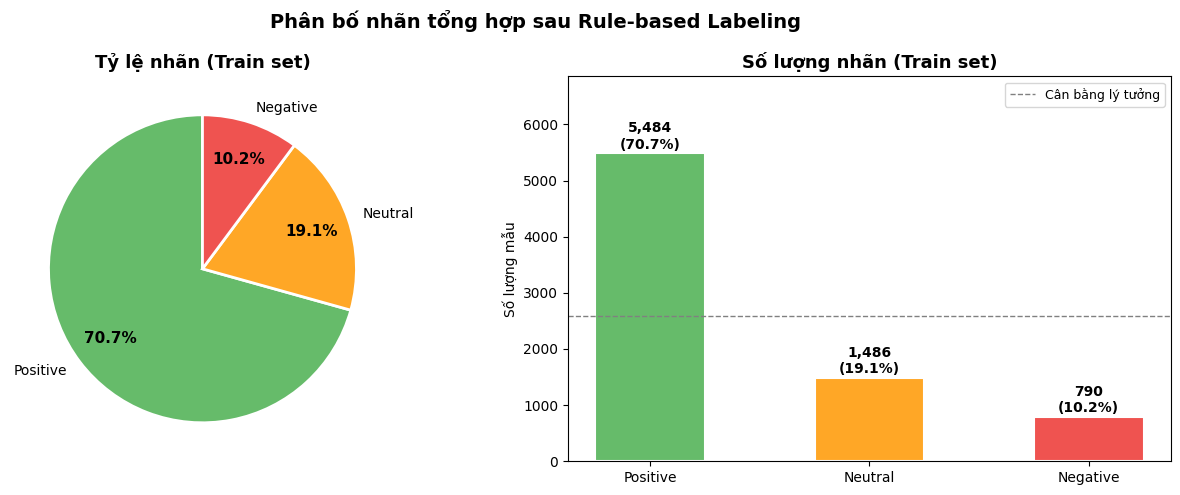

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
wedge_colors = [palette[l] for l in counts.index]

wedges, texts, autotexts = axes[0].pie(
    counts.values, labels=counts.index, colors=wedge_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold')
axes[0].set_title('Tỷ lệ nhãn (Train set)', fontweight='bold', fontsize=13)

bars = axes[1].bar(counts.index, counts.values,
                   color=wedge_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, (label, val) in zip(bars, counts.items()):
    pct = val / total * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Số lượng nhãn (Train set)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Số lượng mẫu')
axes[1].set_ylim(0, counts.max() * 1.25)
axes[1].axhline(y=total/3, color='gray', linestyle='--', linewidth=1, label='Cân bằng lý tưởng')
axes[1].legend(fontsize=9)

plt.suptitle('Phân bố nhãn tổng hợp sau Rule-based Labeling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'sentiment_distribution_eda.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.6.2 Class Weights (Negative=0, Neutral=1, Positive=2)

> ⚠️  Thứ tự `weights_list[0]=Negative, [1]=Neutral, [2]=Positive` phải khớp với tất cả notebook model.


In [18]:
train_df['label'] = train_df['sentiment'].map(LABEL_ENCODE)
val_df['label']   = val_df['sentiment'].map(LABEL_ENCODE)
test_df['label']  = test_df['sentiment'].map(LABEL_ENCODE)

classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'].values)
class_weight_sentiment = {int(c): float(w) for c, w in zip(classes, weights)}

print('=== CLASS WEIGHTS ===')
for cls, w in class_weight_sentiment.items():
    print(f'  {LABEL_DECODE[cls]:10s} ({cls}): {w:.4f}')

# Lưu ra JSON — model notebook load lại, không tính lại
with open(PROC_PATH + 'class_weights.json', 'w', encoding='utf-8') as f:
    json.dump({
        'class_weight_dict': class_weight_sentiment,
        'weights_list'     : list(weights),
        'label_encode'     : LABEL_ENCODE,
        'label_decode'     : {str(k): v for k, v in LABEL_DECODE.items()},
    }, f, indent=2, ensure_ascii=False)

print('\n✅ Đã lưu class_weights.json')


=== CLASS WEIGHTS ===
  Negative   (0): 3.2743
  Neutral    (1): 1.7407
  Positive   (2): 0.4717

✅ Đã lưu class_weights.json


## 3.7 Lưu dữ liệu

In [19]:
# File preprocessed: đủ cột aspect-level
train_df.to_csv(PROC_PATH + 'train_preprocessed.csv', index=False, encoding='utf-8-sig')
val_df.to_csv(PROC_PATH   + 'val_preprocessed.csv',   index=False, encoding='utf-8-sig')
test_df.to_csv(PROC_PATH  + 'test_preprocessed.csv',  index=False, encoding='utf-8-sig')

# ✅ File labeled: Review + sentiment (chữ) + label (số) — bắt buộc có cột 'label'
# Model notebook gọi df['label'].tolist() trực tiếp
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df[['Review', 'sentiment', 'label']].to_csv(
        PROC_PATH + f'{name}_labeled.csv', index=False, encoding='utf-8-sig')

print('✅ Đã lưu thành công:')
print(f'  [data/processed] train_preprocessed.csv  ({len(train_df):,} mẫu)')
print(f'  [data/processed] val_preprocessed.csv    ({len(val_df):,} mẫu)')
print(f'  [data/processed] test_preprocessed.csv   ({len(test_df):,} mẫu)')
print(f'  [data/processed] train_labeled.csv        ({len(train_df):,} mẫu) — Review|sentiment|label')
print(f'  [data/processed] val_labeled.csv          ({len(val_df):,} mẫu)')
print(f'  [data/processed] test_labeled.csv         ({len(test_df):,} mẫu)')
print(f'  [data/processed] class_weights.json')
print(f'  [outputs/figures] sentiment_distribution_eda.png + label_distribution.png')
print()
print('➡️  Bước tiếp theo: notebooks/04_PhoBERT.ipynb')


✅ Đã lưu thành công:
  [data/processed] train_preprocessed.csv  (7,760 mẫu)
  [data/processed] val_preprocessed.csv    (845 mẫu)
  [data/processed] test_preprocessed.csv   (2,146 mẫu)
  [data/processed] train_labeled.csv        (7,760 mẫu) — Review|sentiment|label
  [data/processed] val_labeled.csv          (845 mẫu)
  [data/processed] test_labeled.csv         (2,146 mẫu)
  [data/processed] class_weights.json
  [outputs/figures] sentiment_distribution_eda.png + label_distribution.png

➡️  Bước tiếp theo: notebooks/04_PhoBERT.ipynb
